##Ch3.  기상청 Open API 사용

In [1]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking font

In [15]:
import requests
import json

url = 'http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst'
queryparams ='?'+ \
        'ServiceKey=' + '2e42d539c397208782bf496e597466c7228f5d556411c218ffc66f83f8d88514'+ \
        '&pageNo=' + '1'+ \
        '&numOfRows=' + '1'+ \
        '&dataType=' + 'JSON'+ \
        '&base_date=' + '20260330'+ \
        '&base_time=' + '1400'+\
        '&nx='+ '55'+ \
        '&ny='+ '120'

result = requests.get(url+ queryparams)
print(result.text)

{"response":{"header":{"resultCode":"00","resultMsg":"NORMAL_SERVICE"},"body":{"dataType":"JSON","items":{"item":[{"baseDate":"20260330","baseTime":"1400","category":"TMP","fcstDate":"20260330","fcstTime":"1500","fcstValue":"17","nx":55,"ny":120}]},"pageNo":1,"numOfRows":1,"totalCount":798}}}


In [16]:
import pandas as pd
import json

# Assuming 'result.text' contains the JSON string from the previous API call
data = json.loads(result.text)

# Extract the forecast items
items = data['response']['body']['items']['item']

# Convert to a pandas DataFrame
df = pd.DataFrame(items)

# Filter for temperature ('TMP') category only   #TMP: 1시간 기온 의미
df = df[df['category'] == 'TMP']

# Rename 'fcstValue' column to '예보온도' and 'fcstDate' to '날짜'
df = df.rename(columns={'baseDate':'발표일자','baseTime':'발표시간',
                        'fcstValue': '예보온도', 'fcstDate': '날짜','fcstTime':'예보시간'})

# Convert '예보온도' to numeric, handling potential errors
df['예보온도'] = pd.to_numeric(df['예보온도'], errors='coerce')

# Display the DataFrame
display(df)

,발표일자,발표시간,category,날짜,예보시간,예보온도,nx,ny
0,20260330,1400,TMP,20260330,1500,17,55,120


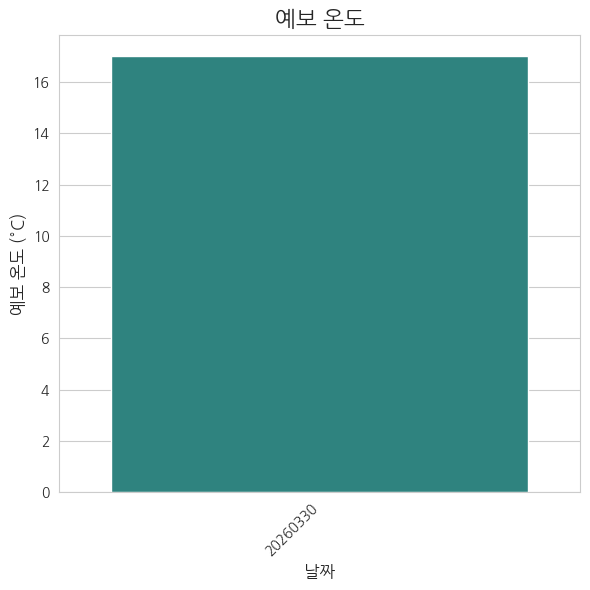

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Configure font to support Korean characters
# Find the path to the NanumGothic font
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'

# Create a bar plot for forecast temperature by date
plt.figure(figsize=(6, 6)) # Increased figure size for more dates
sns.barplot(x='날짜', y='예보온도', data=df, palette='viridis', hue='날짜', legend=False)

# Add title and labels
plt.title('예보 온도', fontsize=16)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('예보 온도 (°C)', fontsize=12)

# Rotate x-axis labels if there are many dates for better readability
plt.xticks(rotation=45, ha='right')

# Display the value on top of the bar (optional for many dates, keep for now)
# for index, row in df.iterrows():
#     plt.text(index, row['예보온도'], str(row['예보온도']), color='black', ha="center", va='bottom')

plt.ylim(bottom=0) # Ensure y-axis starts from 0 for temperature
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()